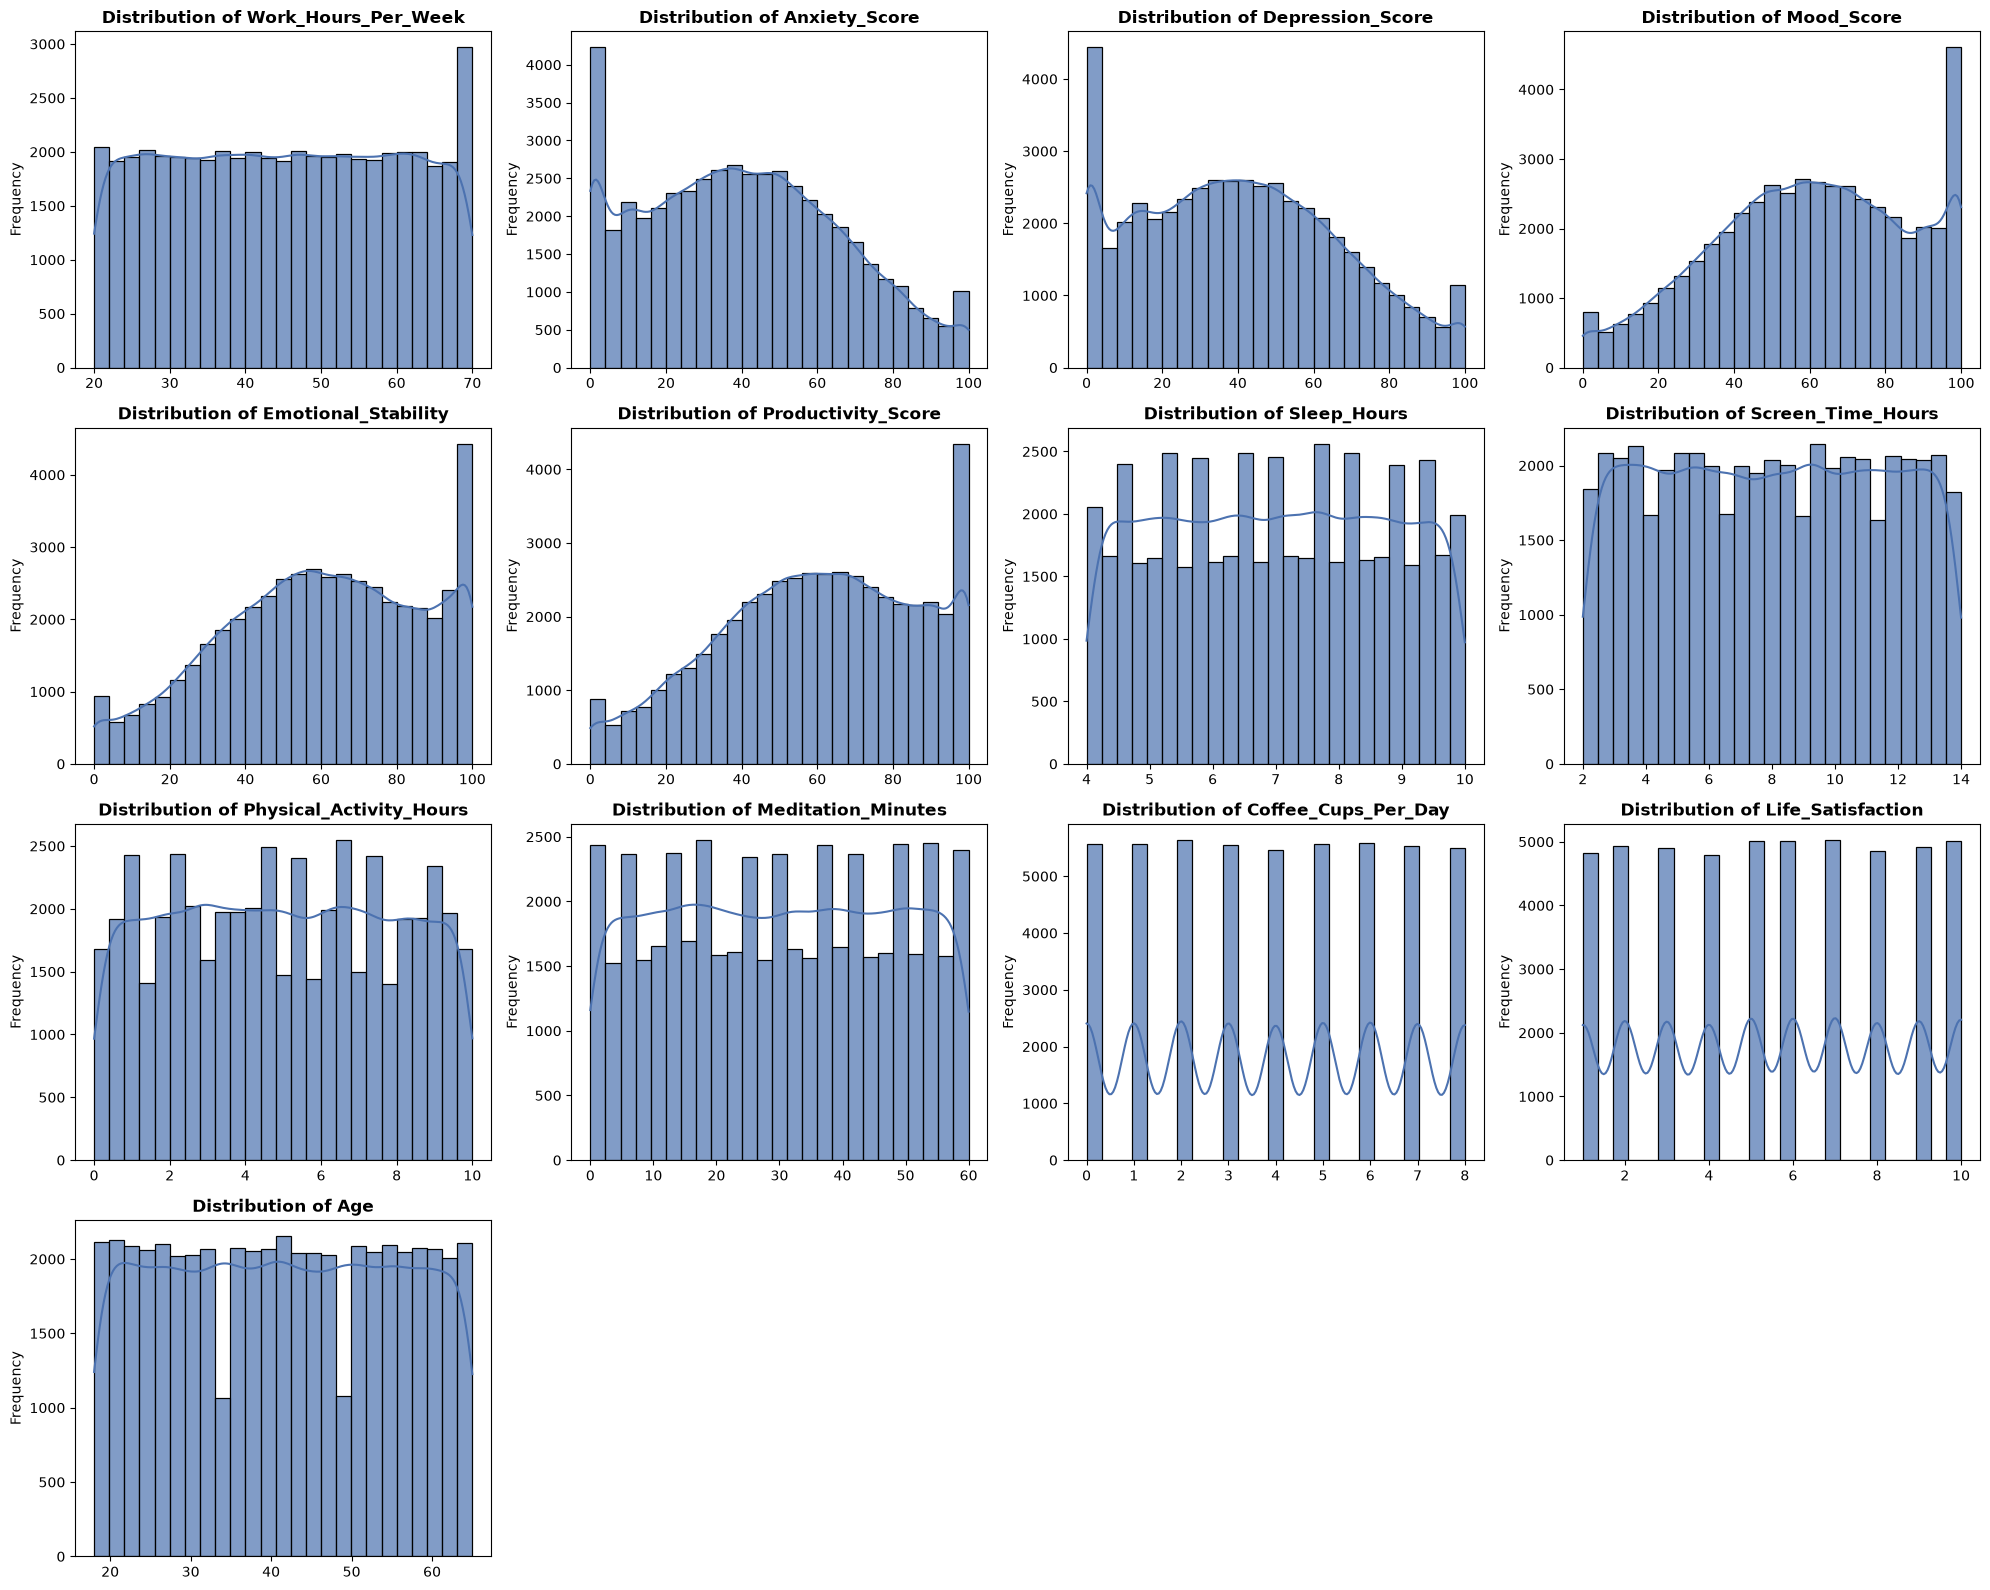

=== DATATYPES ===
Work_Hours_Per_Week          int64
Anxiety_Score              float64
Depression_Score           float64
Mood_Score                 float64
Emotional_Stability          int64
Productivity_Score         float64
Stress_Level                   str
Chronic_Stress                 str
Sleep_Hours                float64
Sleep_Quality                  str
Screen_Time_Hours          float64
Physical_Activity_Hours    float64
Meditation_Minutes         float64
Coffee_Cups_Per_Day          int64
Life_Satisfaction          float64
Age                        float64
Burnout_Risk                   str
dtype: object

=== MISSING VALUES ===
                         Missing Count  Missing %
Meditation_Minutes                1200        2.4
Physical_Activity_Hours           1100        2.2
Productivity_Score                 950        1.9
Sleep_Hours                        950        1.9
Mood_Score                         900        1.8
Depression_Score                   850        1.7

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('cut_data.csv')

num_cols = df.select_dtypes(include=['float64', 'int64']).columns.tolist()

fig, axes = plt.subplots(nrows=4, ncols=4, figsize=(20, 16))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.histplot(df[col].dropna(), kde=True, ax=axes[i], color='#4C72B0', bins=25, edgecolor='black', alpha=0.7)
    
    axes[i].set_title(f'Distribution of {col}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Frequency')

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.savefig('hist_kde_plot.png', dpi=300)
plt.show()

print("=== DATATYPES ===")
print(df.dtypes)

print("\n=== MISSING VALUES ===")
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df) * 100).round(2)
miss_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
miss_df = miss_df[miss_df['Missing Count'] > 0].sort_values('Missing Count', ascending=False)
print(miss_df)
print(f"\nTổng ô thiếu: {missing.sum()}")
print(f"Features bị thiếu: {(missing > 0).sum()}/{len(df.columns)}")

print("\n=== OUTLIER DETECTION (IQR Method) ===")
num_cols = df.select_dtypes(include=['float64', 'int64']).columns.tolist()
outlier_rows = set()

for col in num_cols:
    s = df[col].dropna()
    Q1, Q3 = s.quantile(0.25), s.quantile(0.75)
    IQR = Q3 - Q1
    lb, ub = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    mask = (df[col] < lb) | (df[col] > ub)
    n_out = mask.sum()
    outlier_rows.update(df[mask].index.tolist())
    print(f"  {col:<28} | Outliers: {n_out} ({n_out/len(s)*100:.2f}%) | Range: [{lb:.1f}, {ub:.1f}]")

print(f"\nTổng rows có ít nhất 1 outlier: {len(outlier_rows)}")